# **Imports and Functions**

In [ ]:
!pip install rdkit

import os
import tempfile
import shutil
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import imageio
import tempfile
import copy
import statistics
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 26.8 MB/s eta 0:00:00


In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

def fp_list_from_smiles_list(smiles_list, n_bits=2048):
    fp_list = []
    for smiles in tqdm(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol == None:
            break
        fp_list.append(fp_as_array(mol, n_bits))
    return fp_list

def fp_as_array(mol,n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros((1,), int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def hex_to_RGB(hex_str):
    """ #FFFFFF -> [255,255,255]"""
    #Pass 16 to the integer function for change of base
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):
    """
    Given two hex colors, returns a color gradient
    with n colors.
    """
    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]

# **t-SNE**

In [ ]:
# Combine various groups together and label types
df1 = pd.read_csv('PurchasableFragments.csv')
df1['Type'] = 'Fragment'
df2 = pd.read_csv('UniquePromoietiesOfFDAProdrugs.csv')
df2['Type'] = 'Approved'
df3 = pd.read_csv('InvestigationalProdrugPromoieties.csv')
df3['Type'] = 'Investigational'

dfGRU1 = pd.read_csv('GRU_MolganInput_1.csv')
dfGRU1['Type'] = 'GRU'
dfGRU2 = pd.read_csv('GRU_MolganInput_2.csv')
dfGRU2['Type'] = 'GRU'
dfGRU3 = pd.read_csv('GRU_MolganInput_3.csv')
dfGRU3['Type'] = 'GRU'

all_data_tSNE = pd.concat([df1, df2, df3, dfGRU1, dfGRU2, dfGRU3])
all_data_tSNE = all_data_tSNE.reset_index(drop=True)
all_data_tSNE.to_csv('all_data_tSNE_no_LLM.csv', index = False)

In [ ]:
# Actual t-SNE
dataset = 'all_data_tSNE_no_LLM'

# load your file as a dataframe
# Assumes that your data is in the two column form
df = pd.read_csv('{}.csv'.format(dataset))

fp_list = fp_list_from_smiles_list(df.SMILES)
pca = PCA(n_components=50)
crds = pca.fit_transform(fp_list)

%time crds_embedded = TSNE(n_components=2).fit_transform(crds)
tsne_df = pd.DataFrame(crds_embedded,columns=["X","Y"])
tsne_df['SMILES'] = df['SMILES']
tsne_df['Type'] = df['Type']
tsne_2 = df.merge(tsne_df, left_on=['SMILES', 'Type'], right_on=['SMILES', 'Type'])

Streaming output truncated to the last 5000 lines.
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:28:31] DEPRECATION WARNING: please use MorganGenerator
[13:2

CPU times: user 58.6 s, sys: 52.2 ms, total: 58.7 s
Wall time: 1min 2s


In [ ]:
tsne_2

,SMILES,Type,X,Y
0,NCc1ccccc1C(=O)O,Fragment,67.933784,22.146242
1,OCc1cccc2ccccc12,Fragment,70.865479,0.082472
2,CC(C)(C)c1ccc(C(C)(C)C)cc1,Fragment,39.592735,-3.985220
3,O[SH]1Sc2ccccc2S1,Fragment,61.648441,-6.174294
4,NC(CCCCc1nnn[nH]1)C(=O)O,Fragment,16.051363,50.075409
...,...,...,...,...
5395,CC(CC=CCOBr)=CC=O,GRU,-58.230240,-0.228912
5396,ON=O,GRU,-26.214672,-20.244131
5397,C=CCCCCC[NH1]CC=O,GRU,-58.650356,-19.322508
5398,CCOCC=CC=CCCC=C(N[NH1]C=C=O)OCC=O,GRU,-48.414543,20.109699


In [ ]:
tsne_2.to_csv('{}_promoiety_analysis_no_LLM.csv'.format(dataset), index = False)

# **Plotting**

In [ ]:
tsne_2 = pd.read_csv('all_data_tSNE_no_LLM_promoiety_analysis_no_LLM.csv')

In [ ]:
sns.set(rc={'figure.figsize': (10, 10)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

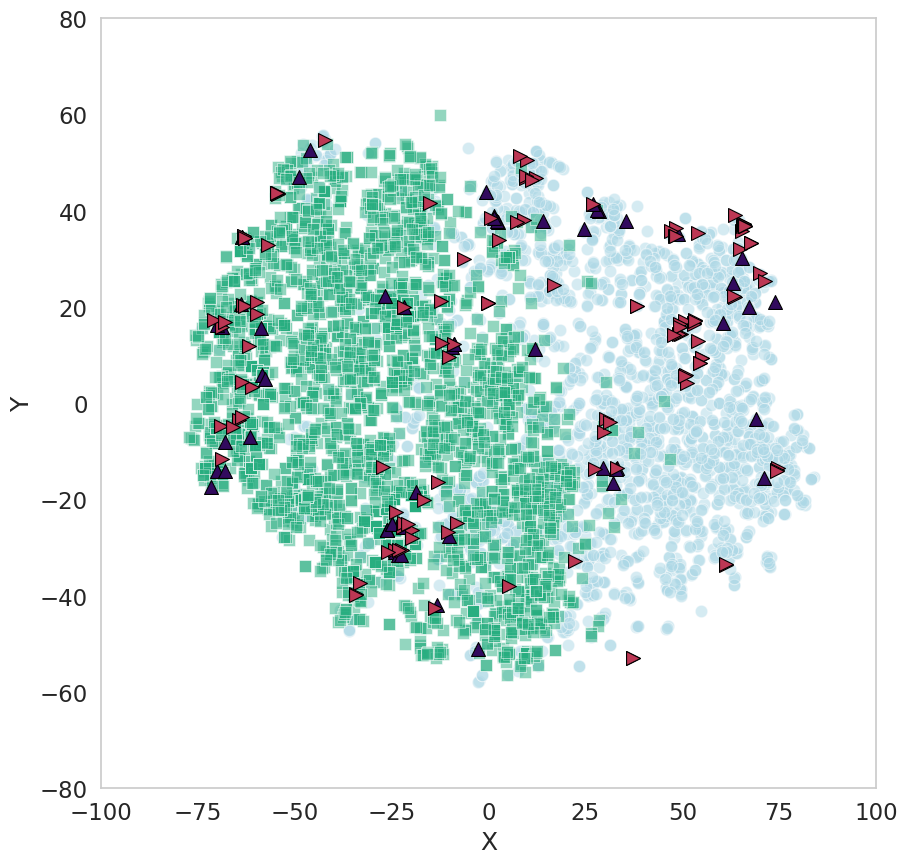

In [ ]:
# Plotting
fig= plt.figure()

# Get datasets
Fragment = tsne_2[tsne_2['Type'] == 'Fragment']
Approved = tsne_2[tsne_2['Type'] == 'Approved']
Investigational = tsne_2[tsne_2['Type'] == 'Investigational']
GRU = tsne_2[tsne_2['Type'] == 'GRU']

# Plot
ax = sns.scatterplot(data=Fragment,x="X",y="Y", color='lightblue', s=80, alpha = 0.5)
ax = sns.scatterplot(data=GRU,x="X",y="Y",color='#28ae80', marker = 's', s=80, alpha = 0.5)
ax = sns.scatterplot(data=Approved,x="X",y="Y",color='#320a5e', edgecolor = 'black', marker = '^', s=100)
ax = sns.scatterplot(data=Investigational,x="X",y="Y",color='#bc3754', edgecolor = 'black', marker = '>', s=100)


ax.set_xlim([-100, 100])
ax.set_ylim([-80, 80])

plt.savefig("all_t-SNE.png", facecolor='white')
files.download("all_t-SNE.png")
plt.grid()
plt.show()